In [1]:
# csv 파일을 처리하는 도구(패키지) 준비
import csv 

In [ ]:
# 데이터 읽기
population_data = []
with open('data-files/population.csv', 'rt', encoding="utf-8") as f:
    rows = csv.reader(f) # csv 형식으로 해석해서 리스트 형식으로 반환
    next(rows) # 한 행 읽기
    for row in rows:
        for idx, d in enumerate(row[1:]):
            if d != '':
                row[idx+1] = int(d.replace(',', ''))
            else:
                row[idx+1] = 0
        
        population_data.append(row)

In [ ]:
print( len(population_data) )
population_data[:2]

In [ ]:
# 성별 인구비가 가장 높은 읍면동 찾기
max_female = 0
max_male = 0
max_male_idx = 0
max_female_idx = 0
for idx, row in enumerate(population_data):
    if row[0][-6] != '0': # 읍면동 데이터만 처리
        mr = row[1] / (row[1] + row[104] + 0.001) # 남자인구비율
        fr = row[104] / (row[1] + row[104] + 0.001) # 여자인구비율
        if mr > max_male:
            max_male = mr
            max_male_idx = idx
        if fr > max_female:
            max_female = fr
            max_female_idx = idx

In [36]:
# population_data[max_male_idx]
# population_data[max_female_idx]

In [41]:
# 지정한 읍면동의 인구 분포 조회
dong = '동선동'
selected_rows = []
for row in population_data:
    if dong in row[0]: # 문자열에 '영등포동'의 포함 여부
        selected_rows.append(row)

# len(selected_rows), selected_rows

In [42]:
male_pop_by_age = selected_rows[0][3:104] # 남자0세 ~ 남자100세이상
female_pop_by_age = selected_rows[0][106:] # 여자0세 ~ 여자100세이상
total_by_age = [ male + female for male, female in zip(male_pop_by_age, female_pop_by_age) ]

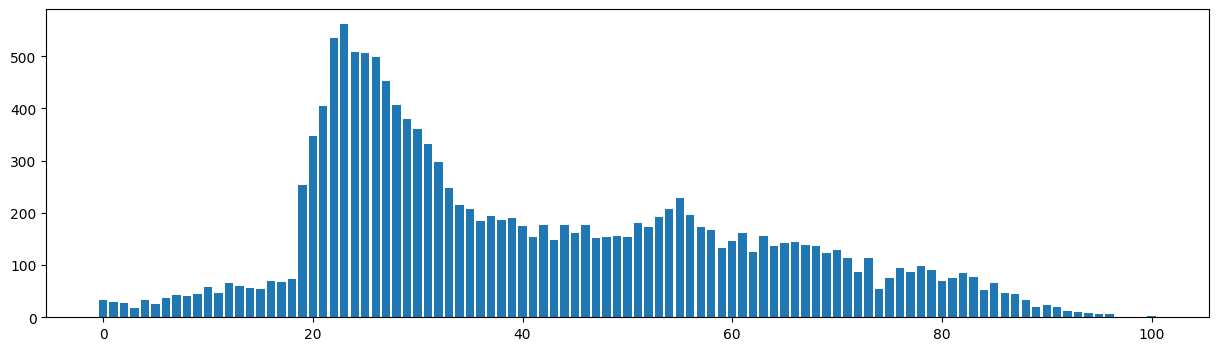

In [43]:
# 전체 인구 분포 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.bar(range(0, 101), total_by_age)
plt.show()

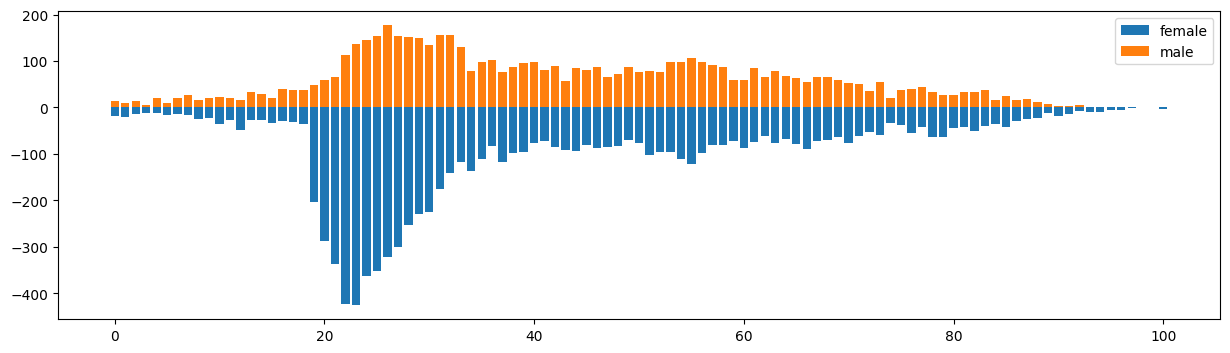

In [44]:
# 남여 인구 분포 시각화
import matplotlib.pyplot as plt

female_pop_by_age2 = [ -p for p in female_pop_by_age ]

plt.figure(figsize=(15, 4))
plt.bar(range(0, 101), female_pop_by_age2, label='female')
plt.bar(range(0, 101), male_pop_by_age, label='male')
plt.legend()
plt.show()

In [1]:
# csv 파일을 처리하는 도구(패키지) 준비
import csv 

In [2]:
# 데이터 읽기
population_data = []
with open('data-files/population.csv', 'rt', encoding="utf-8") as f:
    rows = csv.reader(f) # csv 형식으로 해석해서 리스트 형식으로 반환
    next(rows) # 한 행 읽기
    for row in rows:
        for idx, d in enumerate(row[1:]):
            if d != '':
                row[idx+1] = int(d.replace(',', ''))
            else:
                row[idx+1] = 0
        
        population_data.append(row)

In [3]:
# 성별 인구비가 가장 높은 읍면동 찾기 함수 만들기
def select_dong_by_gender_ratio(gender='male', count=1):
    max_ratio = 0
    max_idx = 0
    for idx, row in enumerate(population_data):
        if row[0][-6] != '0': # 읍면동 데이터만 처리
            if gender == 'male':
                ratio = row[1] / (row[1] + row[104] + 0.00001) # 남자인구비율
            else:
                ratio = row[104] / (row[1] + row[104] + 0.00001) # 여자인구비율
            if ratio > max_ratio:
                max_ratio = ratio
                max_idx = idx

    return population_data[max_idx]
            

In [4]:
selected_dong = select_dong_by_gender_ratio('female')
print(selected_dong)

['서울특별시 성북구 동선동(1129057500)', 5864, 5864, 15, 9, 14, 6, 21, 9, 21, 27, 16, 21, 23, 20, 17, 33, 30, 21, 40, 37, 38, 49, 60, 66, 112, 136, 146, 154, 177, 153, 152, 149, 135, 157, 157, 130, 79, 97, 102, 76, 88, 96, 97, 81, 90, 58, 84, 80, 88, 66, 72, 87, 76, 79, 77, 97, 97, 107, 98, 92, 87, 60, 60, 86, 65, 79, 68, 63, 55, 65, 66, 59, 52, 51, 35, 54, 20, 38, 39, 44, 34, 27, 26, 33, 34, 37, 17, 24, 16, 19, 11, 7, 4, 4, 5, 1, 0, 2, 1, 0, 0, 1, 0, 8729, 8729, 19, 20, 13, 12, 12, 16, 15, 16, 25, 23, 35, 27, 49, 27, 26, 34, 29, 31, 36, 204, 287, 338, 423, 426, 362, 353, 321, 300, 254, 230, 226, 175, 141, 117, 136, 111, 83, 118, 99, 95, 77, 72, 86, 91, 93, 81, 88, 85, 82, 69, 77, 102, 96, 95, 111, 122, 97, 81, 80, 73, 87, 75, 61, 76, 68, 79, 90, 73, 70, 64, 76, 62, 52, 59, 34, 37, 56, 42, 64, 63, 44, 42, 50, 40, 36, 42, 30, 25, 23, 12, 19, 15, 7, 10, 9, 5, 6, 1, 0, 0, 3]


In [5]:
selected_dong = select_dong_by_gender_ratio('male')
print(selected_dong)

['경기도 파주시 월롱면(4148031000)', 4909, 4909, 2, 6, 3, 5, 2, 5, 2, 6, 6, 10, 7, 7, 17, 9, 11, 7, 14, 8, 19, 9, 15, 12, 17, 18, 32, 45, 129, 203, 224, 212, 182, 166, 135, 96, 67, 67, 70, 76, 71, 71, 78, 63, 72, 74, 82, 75, 75, 61, 61, 52, 64, 78, 88, 78, 92, 93, 98, 78, 87, 81, 77, 76, 67, 95, 97, 95, 88, 74, 62, 62, 56, 43, 36, 53, 26, 32, 32, 34, 34, 25, 14, 18, 19, 22, 14, 17, 8, 5, 10, 6, 4, 5, 1, 3, 2, 2, 1, 0, 1, 0, 0, 2673, 2673, 7, 2, 5, 4, 3, 3, 0, 5, 11, 8, 9, 9, 9, 12, 11, 7, 11, 5, 12, 14, 6, 9, 15, 16, 26, 31, 65, 77, 78, 45, 33, 43, 36, 38, 22, 21, 26, 26, 22, 24, 21, 16, 25, 25, 23, 19, 24, 23, 32, 26, 25, 25, 43, 33, 39, 47, 43, 60, 47, 52, 59, 57, 56, 68, 66, 53, 59, 50, 59, 49, 60, 33, 42, 40, 26, 41, 23, 29, 29, 22, 31, 22, 32, 33, 17, 20, 24, 25, 20, 12, 19, 10, 6, 9, 6, 3, 2, 3, 1, 0, 3]


In [11]:
# 특정 연령대 인구비율이 높은 읍면동 찾기
# 3 : 남성 0세
# 103 : 남성 100세
# 106 : 여성 0세
# 206 : 여성 100세

def find_dong_by_age_ratio(min_age, max_age, min_pop=5000):
    max_ratio = 0
    max_idx = 0
    for idx, row in enumerate(population_data):
        if row[0][-6] != '0': # 읍면동 데이터만 처리
            total = row[1] + row[104] + 0.00001 # 총인구수
            if total >= min_pop:
                male = sum(row[min_age + 3:max_age + 3])
                female = sum(row[min_age + 106:max_age + 106])
                ratio = (male + female) / total            
                if ratio > max_ratio:
                    max_ratio = ratio
                    max_idx = idx

    return population_data[max_idx]

In [ ]:
selected_dong1 = find_dong_by_age_ratio(61, 100)
selected_dong1

In [ ]:
selected_dong2 = find_dong_by_age_ratio(20, 50)
selected_dong2

In [17]:
# 지정한 읍면동의 인구 분포 조회
dong = '소원면'
selected_rows1 = []
for row in population_data:
    if dong in row[0]: 
        selected_rows1.append(row)

dong = '신림동'
selected_rows2 = []
for row in population_data:
    if dong in row[0]: 
        selected_rows2.append(row)

In [18]:
total_by_age1 = [ male + female for male, female 
                                in zip(selected_rows1[0][3:104], selected_rows1[0][106:]) ]
total_by_age2 = [ male + female for male, female 
                                in zip(selected_rows2[0][3:104], selected_rows2[0][106:]) ]

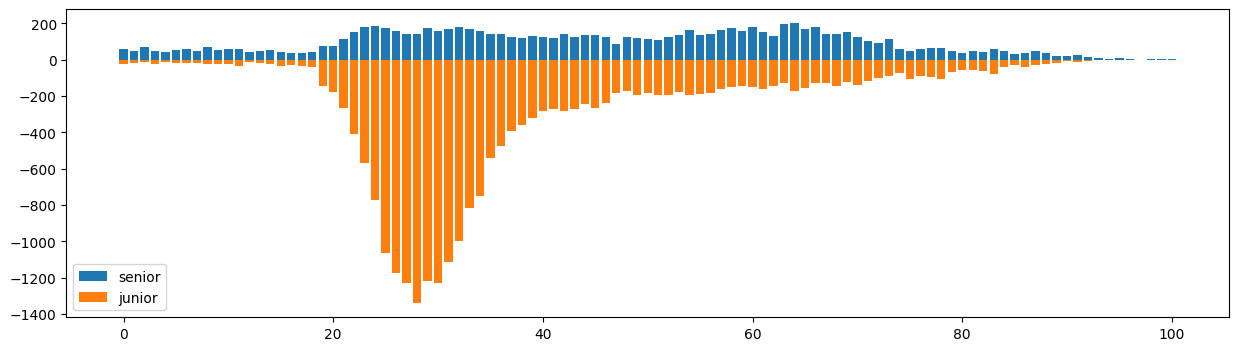

In [23]:
import matplotlib.pyplot as plt

total_by_age3 = [ -p for p in total_by_age2 ]

plt.figure(figsize=(15, 4))
plt.bar(range(0, 101), total_by_age1, label='senior')
plt.bar(range(0, 101), total_by_age3, label='junior')
plt.legend()
plt.show()